In [1]:
# importing required libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os
import kagglehub # library to pull Kaggle data directly in Colab
import matplotlib.pyplot as plt

In [2]:
# step 01
# If a GPU is listed, Keras will automatically use it during training.
# Check that TensorFlow can see your GPU(s)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

# (Optional) Enable memory growth so TF doesn’t grab all GPU memory at once
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print("Memory growth error:", e)
else:
    print("No GPU detected, training will run on CPU.")

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth enabled for GPUs.


In [3]:
# step 02
# Download CIFAR-10 dataset from Kaggle (RGB 32x32 images). (32, 32, 3)
path = kagglehub.dataset_download("ayush1220/cifar10")
print("Dataset downloaded to:", path)

data_dir = path  # from kagglehub.dataset_download

print("Version dir:", data_dir)
print("Inside version dir:", os.listdir(data_dir))

inner_dir = os.path.join(data_dir, "cifar10")
print("Inner dir:", inner_dir)
print("Inside inner dir:", os.listdir(inner_dir))

Using Colab cache for faster access to the 'cifar10' dataset.
Dataset downloaded to: /kaggle/input/cifar10
Version dir: /kaggle/input/cifar10
Inside version dir: ['cifar10']
Inner dir: /kaggle/input/cifar10/cifar10
Inside inner dir: ['test', 'train']


In [4]:
# step 03
# loading train data into train_dir and test data into test_dir
#version_dir = "/root/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2"
version_dir = "/kaggle/input/cifar10"
data_dir = os.path.join(version_dir, "cifar10")
train_dir = os.path.join(data_dir, "train")
test_dir  = os.path.join(data_dir, "test")

print("Train dir:", train_dir)
print("Test dir:", test_dir)
print("Train classes:", os.listdir(train_dir))

Train dir: /kaggle/input/cifar10/cifar10/train
Test dir: /kaggle/input/cifar10/cifar10/test
Train classes: ['airplane', 'horse', 'truck', 'automobile', 'ship', 'dog', 'bird', 'frog', 'cat', 'deer']


In [5]:
# step 04
# creating tf.data.Dataset by loading train dataset from train_dir and test dataset from test_dir
# later train dataset splits into train and validation dataset

img_size = (32, 32)
batch_size = 16

# Train+val from train_dir (Keras will infer class names from subfolders)
train_val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2,  # 80% train, 20% val from training data
    subset="both",
    seed=42,
)

train_ds, val_ds = train_val_ds

# Test from test_dir
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
)

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


In [6]:
# step 05
# creating list of class names and checking total number of classes (required for model build)
class_names = train_ds.class_names
print("Class names:", class_names)
num_classes = len(class_names)
print(f"Number of classes {num_classes}")

Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Number of classes 10


Batch images shape: (16, 32, 32, 3)
Batch labels shape: (16,)


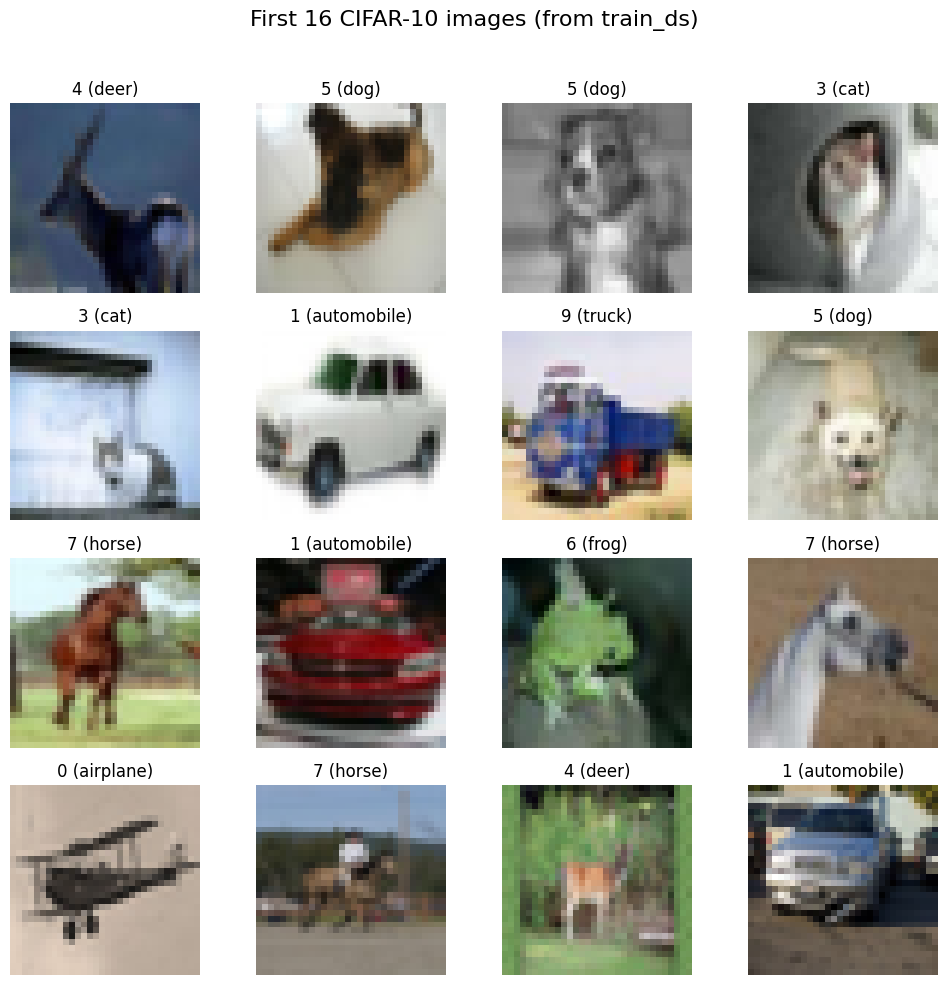

In [7]:
# step 06
# visualizing first 16 CIFAR-10 image data

images_batch, labels_batch = next(iter(train_ds))
print("Batch images shape:", images_batch.shape)
print("Batch labels shape:", labels_batch.shape)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 CIFAR-10 images (from train_ds)", fontsize=16)

for i, ax in enumerate(axes.flat):
    if i >= images_batch.shape[0]:
        break
    img = images_batch[i].numpy().astype("uint8")
    label_idx = int(labels_batch[i])
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"{label_idx} ({class_names[label_idx]})")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [8]:
# step 07
# Normalizing data (CNNs usually work better when input pixels are normalized to [0, 1].)

# (better not to normalize for pretrained model because pretrained model scale input data accordingly the model was trained)
# normalization_layer = layers.Rescaling(1.0 / 255.0)

# def norm_map(x, y):
#     return normalization_layer(x), y

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [9]:
# step 08
# defining lambda value (L2 regularization factor (weight decay strength))
weight_decay = 1e-4

**MobileNetV2**

In [11]:
# step 09
# building (creating) the model

IMG_SIZE = (32, 32)

# Pretrained backbone: MobileNetV2
base_model = keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3), # model will take 128 x 128 image
    )

base_model.trainable = False  # freeze backbone for first phase

# Add CIFAR-10 classifier head (BN, L2, Dropout)
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)) # CIFAR10 dataset image (32 x 32, 3)

x = layers.Resizing(128, 128)(inputs) # rescaling CIFAR10 image to model input shape

# Ensure correct scaling for MobileNetV2 (no manual /255 before this)
x = keras.applications.mobilenet_v2.preprocess_input(x)

# Pass through pretrained backbone
x = base_model(x, training=False)

# Global pooling + head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
    )(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

mobilenet_model = keras.Model(inputs, outputs)

In [12]:
# step 10
# compiling the model

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [13]:
# step 11
# training the model with epoch 20

epochs = 20

callbacks = [
    # EarlyStopping: stop training if val_loss(monitor) doesn’t improve for 5 epochs(patience),
    # and restore the model weights from the epoch with the best val_loss)(restore_best_weights).

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    # ReduceLROnPlateau: if val_loss(monitor) stops improving for 2 epochs(patience),
    # cut the learning rate in half(factor) to help the optimizer make finer updates.

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history = mobilenet_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/20
2500/2500 - 119s - 48ms/step - accuracy: 0.7721 - loss: 0.7764 - val_accuracy: 0.8441 - val_loss: 0.5349 - learning_rate: 0.0010
Epoch 2/20
2500/2500 - 22s - 9ms/step - accuracy: 0.8229 - loss: 0.6109 - val_accuracy: 0.8441 - val_loss: 0.5777 - learning_rate: 0.0010
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2500/2500 - 21s - 8ms/step - accuracy: 0.8401 - loss: 0.5916 - val_accuracy: 0.8467 - val_loss: 0.6077 - learning_rate: 0.0010
Epoch 4/20
2500/2500 - 22s - 9ms/step - accuracy: 0.8766 - loss: 0.4923 - val_accuracy: 0.8602 - val_loss: 0.5721 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [14]:
# step 14
# Evaluating the model
test_loss, test_acc = mobilenet_model.evaluate(test_ds, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

625/625 - 22s - 35ms/step - accuracy: 0.8396 - loss: 0.5235
Test loss: 0.5235339999198914
Test accuracy: 0.8396000266075134


**ResNet50V2**

In [15]:
# step 09
# building (creating) the model

IMG_SIZE = (32, 32)

base_model = keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3),
)

base_model.trainable = False  # freeze backbone for first phase

# Add CIFAR-10 classifier head (BN, L2, Dropout)
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)) # CIFAR10 dataset image (32 x 32, 3)

x = layers.Resizing(128, 128)(inputs) # rescaling CIFAR10 image to model input shape

# Ensure correct scaling for MobileNetV2 (no manual /255 before this)
x = keras.applications.resnet_v2.preprocess_input(x)

# Pass through pretrained backbone
x = base_model(x, training=False)

# Global pooling + head
# GlobalAveragePooling2D collapses each feature map to a single mean value,
# turning the 2D spatial maps into a 1D feature vector (batch, channels)
# with no extra parameters; this is a simple, low‑overfitting way to
# summarize features before the Dense layers, instead of using a big
# Flatten or another MaxPooling.
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
    )(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

resnetv2_model = keras.Model(inputs, outputs)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [16]:
# step 10
# compiling the model

resnetv2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [17]:
# step 11
# training the model with epoch 20

epochs = 20

callbacks = [
    # EarlyStopping: stop training if val_loss(monitor) doesn’t improve for 5 epochs(patience),
    # and restore the model weights from the epoch with the best val_loss)(restore_best_weights).

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    # ReduceLROnPlateau: if val_loss(monitor) stops improving for 2 epochs(patience),
    # cut the learning rate in half(factor) to help the optimizer make finer updates.

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history = resnetv2_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/20
2500/2500 - 65s - 26ms/step - accuracy: 0.7504 - loss: 0.8582 - val_accuracy: 0.8243 - val_loss: 0.6194 - learning_rate: 0.0010
Epoch 2/20
2500/2500 - 49s - 20ms/step - accuracy: 0.8075 - loss: 0.6992 - val_accuracy: 0.8255 - val_loss: 0.6600 - learning_rate: 0.0010
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2500/2500 - 50s - 20ms/step - accuracy: 0.8234 - loss: 0.6866 - val_accuracy: 0.8371 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 4/20
2500/2500 - 81s - 33ms/step - accuracy: 0.8693 - loss: 0.5611 - val_accuracy: 0.8490 - val_loss: 0.6455 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [18]:
# step 14
# Evaluating the model
test_loss, test_acc = resnetv2_model.evaluate(test_ds, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

625/625 - 10s - 15ms/step - accuracy: 0.8193 - loss: 0.6348
Test loss: 0.6347907185554504
Test accuracy: 0.8192999958992004


**EfficientNetV2B0**

In [20]:
# step 09
# building (creating) the model

IMG_SIZE = (32, 32)

base_model = keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(128, 128, 3),
)

base_model.trainable = False  # freeze backbone for first phase

# Add CIFAR-10 classifier head (BN, L2, Dropout)
inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)) # CIFAR10 dataset image (32 x 32, 3)

x = layers.Resizing(128, 128)(inputs) # rescaling CIFAR10 image to model input shape

# Ensure correct scaling for MobileNetV2 (no manual /255 before this)
x = keras.applications.efficientnet_v2.preprocess_input(x)

# Pass through pretrained backbone
x = base_model(x, training=False)

# Global pooling + head
# GlobalAveragePooling2D collapses each feature map to a single mean value,
# turning the 2D spatial maps into a 1D feature vector (batch, channels)
# with no extra parameters; this is a simple, low‑overfitting way to
# summarize features before the Dense layers, instead of using a big
# Flatten or another MaxPooling.
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(
    256,
    activation="relu",
    kernel_regularizer=keras.regularizers.l2(1e-4),
    )(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

efficientNetv2_model = keras.Model(inputs, outputs)

In [21]:
# step 10
# compiling the model

efficientNetv2_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [22]:
# step 11
# training the model with epoch 20

epochs = 20

callbacks = [
    # EarlyStopping: stop training if val_loss(monitor) doesn’t improve for 5 epochs(patience),
    # and restore the model weights from the epoch with the best val_loss)(restore_best_weights).

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    # ReduceLROnPlateau: if val_loss(monitor) stops improving for 2 epochs(patience),
    # cut the learning rate in half(factor) to help the optimizer make finer updates.

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1,
    ),
]

history = efficientNetv2_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=2,
)

Epoch 1/20
2500/2500 - 66s - 26ms/step - accuracy: 0.8226 - loss: 0.6386 - val_accuracy: 0.8947 - val_loss: 0.3871 - learning_rate: 0.0010
Epoch 2/20
2500/2500 - 29s - 11ms/step - accuracy: 0.8590 - loss: 0.5183 - val_accuracy: 0.9033 - val_loss: 0.3978 - learning_rate: 0.0010
Epoch 3/20

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2500/2500 - 29s - 12ms/step - accuracy: 0.8705 - loss: 0.5092 - val_accuracy: 0.9033 - val_loss: 0.4315 - learning_rate: 0.0010
Epoch 4/20
2500/2500 - 28s - 11ms/step - accuracy: 0.8925 - loss: 0.4518 - val_accuracy: 0.9057 - val_loss: 0.4096 - learning_rate: 5.0000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


In [23]:
# step 14
# Evaluating the model
test_loss, test_acc = efficientNetv2_model.evaluate(test_ds, verbose=2)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

625/625 - 6s - 10ms/step - accuracy: 0.8914 - loss: 0.4019
Test loss: 0.40188145637512207
Test accuracy: 0.8913999795913696
